In [9]:
import os, sys, imaplib
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import _cm
import numpy as np


In [10]:
## data :
path_df=r"../results\vol1\vol1-combined_table-index_theme_notice.csv"
df=pd.read_csv(path_df)
print(df.shape)
print(df.columns.to_list())

(622, 14)
['title_theme', 'title_index', 'author', 'theme', 'cycle', 'collection', 'mss_ff', 'mss', 'ff', 'page', 'mss_index', 'material_class', 'size_class', 'cent_i']


In [11]:
display(df.head())

,title_theme,title_index,author,theme,cycle,collection,mss_ff,mss,ff,page,mss_index,material_class,size_class,cent_i
0,heroica,heroica,flavius philostratus,classical romances,cycle of troy,royal,16. c. xxiii. ff. 2-69 b,16. c. xxiii.,ff. 2-69 b,1,royal 16. c. xxiii. ff. 2-69 b,vellum,quarto,15.0
1,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,royal,16. c. iv. a. b.,16. c. iv. a. b.,NaN,2,royal 16. c. iv. a. b.,paper,quarto,16.0
2,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,royal,16. d. iii. a. b.,16. d. iii. a. b.,NaN,2,royal 16. d. iii. a. b.,paper,NaN,6.0
3,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,harley,harley 5662. ff. 1-56,harley 5662.,ff. 1-56,2,harley 5662. ff. 1-56,paper,quarto,15.0
4,dictys cretensis,dictys cretensis,NaN,classical romances,cycle of troy,harley,harley 3514,harley 3514,NaN,9,harley 3514,vellum,octavo,15.0


In [12]:
df=df.dropna(subset=['mss'])
print(len(df))
df.mss.value_counts(dropna=False)

587


mss
add. 27879          14
caligula a. ii.     10
15. e. vi.           9
add. 4859.           7
caligula b. vii.     6
                    ..
16. c. xxiii.        1
egerton 2515         1
add. 4875.           1
harley 6148.         1
lansdowne 214.       1
Name: count, Length: 393, dtype: int64

## bipartite network
| source             | target | type        |
| ------------------ | ------ | ----------- |
| alexandreis        | MS A   | text_in_mss |
| turpin's chronicle | MS A   | text_in_mss |


In [13]:
print(df[['title_index',"mss"]].value_counts(dropna=False))

title_index                    mss         
alexandreis                    add. 22,821     4
                               harley 5437     4
                               harley 4745     4
                               burney 312      4
turpin's chronicle             nero a. xi.     4
                                              ..
valentine and orson and tales  add. 11,157.    1
alexander saga                 add. 24,969.    1
alexander the great            13. a. v.       1
vita merlini                   13. e. i.       1
                               harley 655.     1
Name: count, Length: 502, dtype: int64


                   title_index                 mss
0                      heroica       16. c. xxiii.
1                       iliaca    16. c. iv. a. b.
2                       iliaca   16. d. iii. a. b.
3                       iliaca        harley 5662.
4             dictys cretensis         harley 3514
..                         ...                 ...
617                 a propecye  add. 27879 f 239 b
618       robin hood's garland          add. 28638
619        ballads of scotland   add. 29408, 29409
620   two charlemagne romances          add. 31042
621  ipomedon and prothesilaus        egerton 2515

[587 rows x 2 columns]


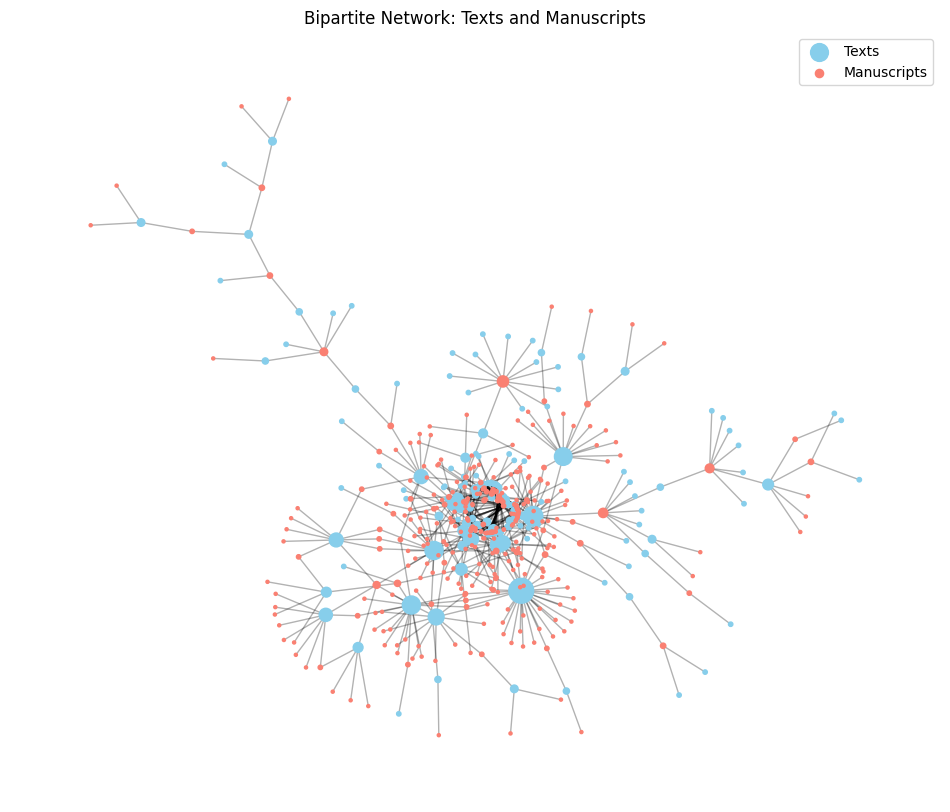

In [14]:
# DATA
edges = df[['title_index',"mss"]].dropna() # "mss"
print(edges)

edges.columns = ['source', 'target']
edges['type'] = 'text_in_mss'


# VIS
B = nx.Graph()
B.add_nodes_from(edges['source'], bipartite=0)  # texts
B.add_nodes_from(edges['target'], bipartite=1)  # mss
B.add_edges_from(zip(edges['source'], edges['target']))

# 布局
# pos = nx.spring_layout(B, k=0.3)
# pos = nx.spring_layout(B, k=2, iterations=100, seed=42)# k越大，节点越分散
pos = nx.kamada_kawai_layout(B, scale=3)#节点分布更加均匀


# 🎯 分离两类节点
texts = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
mss = [n for n, d in B.nodes(data=True) if d['bipartite'] == 1]

# 🎨 画图
plt.figure(figsize=(12,10))

# 边
degree = dict(B.degree())
text_sizes = [degree[n]*10 for n in texts]
mss_sizes = [degree[n]*5 for n in mss]

# text 节点（蓝色，大一点）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=texts,
    node_color='skyblue',
    node_size=text_sizes,
    label='Texts'
)

# mss 节点（红色，小一点）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=mss,
    node_color='salmon',
    node_size=mss_sizes,
    label='Manuscripts'
)

nx.draw_networkx_edges(B, pos, alpha=0.3)

plt.legend()
plt.title("Bipartite Network: Texts and Manuscripts")
plt.axis('off')
plt.show()

In [15]:
# Caractéristiques du graphe:
# On regarde parmi toutes les possibilités.

print("Connexe:", nx.is_connected(B))
if not nx.is_connected(B):
    print("Nombre de composantes connexes:", nx.number_connected_components(B))
else:
    print("Diameter", nx.diameter(B))
print("Densité:", nx.density(B))

print("*"*50)
print("Connectivité algébrique:", nx.algebraic_connectivity(B))
print("Spectral_ordering:", nx.spectral_ordering(B))

print("Spectres")
print("\t*Matrice adjacence", [float(elem.real) for elem in nx.adjacency_spectrum(B)])
print("\t*Matrice laplacienne", nx.laplacian_spectrum(B))

Connexe: False
Nombre de composantes connexes: 137
Densité: 0.002616082130387201
**************************************************
Connectivité algébrique: 0.0
Spectral_ordering: ['heroica', '16. c. xxiii.', 'harley 5662.', 'iliaca', '16. c. iv. a. b.', '16. d. iii. a. b.', 'harley 3514', 'add. 15,429', 'dictys cretensis', 'burney 170', 'richard coeur-de-lion', 'two charlemagne romances', 'add. 31042', 'juglet', 'add. 10,289.', '16. e. viii.', 'add. 10,038.', 'vespasian e. xvi.', 'titus and vespasian', 'sir eglamour of artois', 'sir launfal', 'octavian the emperor', 'sir isumbras', 'lybeaus desconus', 'emare', 'caligula a. ii.', 'knight of the swan', 'romance of the peers of france', 'add. 10,508.', 'sloane 960', '16. g. ii.', 'aspremont', 'quatre fils aimon', 'ogier le danois', 'simon de pouille', 'fierabras', 'pontus and sidoine', 'guy of warwick and heraud of ardennes', '15. e. vi.', '13. e. ix.', 'cotton appendix iv.', 'prophecies of merlin silvester', '14. c. i.', 'historia regum

In [16]:
# Liste de la taille de chaque composante
comp_sizes = [len(c) for c in nx.connected_components(B)]
print(f"Taille de la plus grosse composante : {max(comp_sizes)}")
print(sorted(comp_sizes))
print(sum(comp_sizes))

Taille de la plus grosse composante : 202
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 6, 7, 7, 8, 9, 9, 9, 12, 13, 36, 202]
620


                   title_index  collection
0                      heroica       royal
1                       iliaca       royal
2                       iliaca       royal
3                       iliaca      harley
4             dictys cretensis      harley
..                         ...         ...
617                 a propecye  additional
618       robin hood's garland  additional
619        ballads of scotland  additional
620   two charlemagne romances  additional
621  ipomedon and prothesilaus     egerton

[587 rows x 2 columns]


C:\Users\mathi\AppData\Local\Temp\ipykernel_18380\1855107556.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


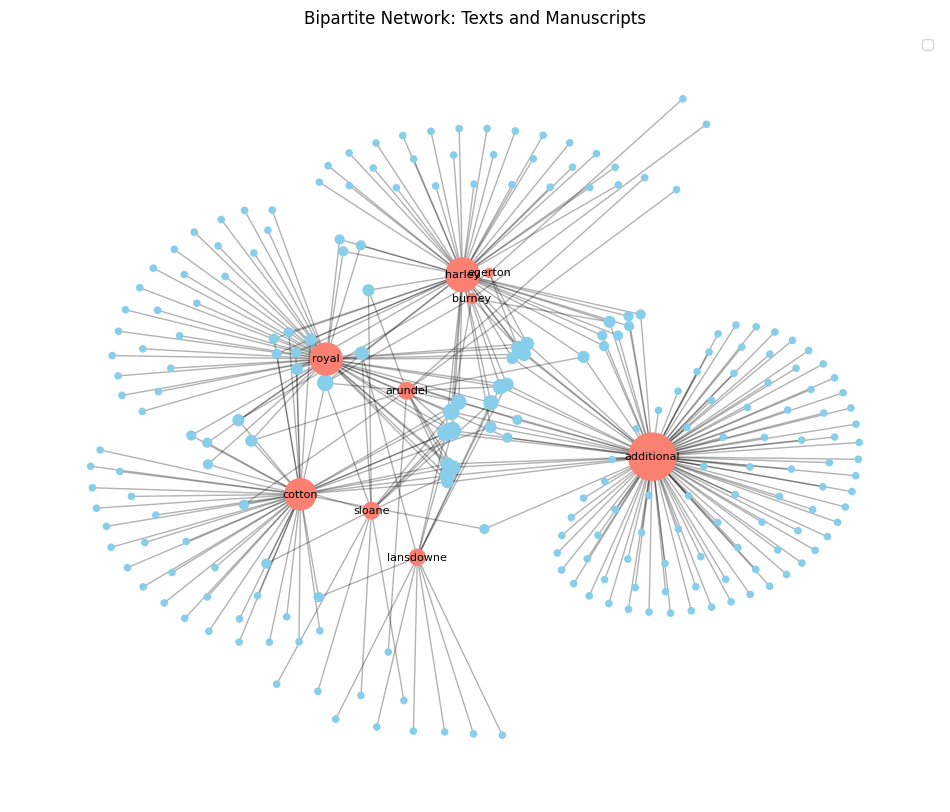

In [17]:
# DATA
edges = df[['title_index', 'collection']].dropna()
print(edges)

edges.columns = ['source', 'target']
edges['type'] = 'text_in_mss'


# VIS
B = nx.Graph()
B.add_nodes_from(edges['source'], bipartite=0)  # texts
B.add_nodes_from(edges['target'], bipartite=1)  # mss
B.add_edges_from(zip(edges['source'], edges['target']))

# 布局
# pos = nx.spring_layout(B, k=0.3)
# pos = nx.spring_layout(B, k=1.2, iterations=100, seed=42)# k越大，节点越分散
pos = nx.kamada_kawai_layout(B)#节点分布更加均匀
# 🎯 分离两类节点
texts = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
mss = [n for n, d in B.nodes(data=True) if d['bipartite'] == 1]

# 🎨 画图
plt.figure(figsize=(12,10))

# 边
degree = dict(B.degree())
text_sizes = [degree[n]*20 for n in texts]
mss_sizes = [degree[n]*10 for n in mss]



# text 节点（蓝色）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=texts,
    node_color='skyblue',
    node_size=text_sizes,
    # label='Texts'
)

# mss 节点（红色）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=mss,
    node_color='salmon',
    node_size=mss_sizes,
    # label='Manuscripts'
)

# 
labels = {node: node for node in mss}
nx.draw_networkx_labels(
    B, pos,
    labels=labels,
    font_size=8,
    font_color='black'
)



nx.draw_networkx_edges(B, pos, alpha=0.3)

plt.legend()
plt.title("Bipartite Network: Texts and Manuscripts")
plt.axis('off')
plt.show()

# projection network

## commmunity detection

In [18]:
from itertools import combinations
import pandas as pd

df_=df.copy()

df_=df_.dropna(subset=['theme'])
print(len(df), len(df_))
print(df_[["theme","mss"]].value_counts(dropna=False),"\n")


edges = []

for mss, group in df_.groupby('mss'):#按mss分组
    titles = group['title_index'].dropna().unique()# 提取一个mss中所有的title
    
    for pair in combinations(titles, 2):#两两配对
        edges.append(pair)

proj_df = pd.DataFrame(edges, columns=['source', 'target'])

# 计算权重（共现次数）
proj_df['weight'] = 1
proj_df = proj_df.groupby(['source','target']).sum().reset_index()
display(proj_df)
print(proj_df[['source',"target"]].value_counts())

# proj_df.to_csv("text_projection.csv", index=False)

587 413
theme                             mss          
british and english traditions    add. 27879       7
french traditions                 15. e. vi.       5
classical romances                8. b. iv.        4
                                  burney 312       4
                                  15. a. x.        4
                                                  ..
allegorical and didactic romance  lansdowne 793    1
                                  sloane 2232      1
appendix                          add. 16,956      1
                                  13. d. i.        1
classical romances                sloane 2233      1
Name: count, Length: 331, dtype: int64 



,source,target,weight
0,apollonius of tyre,cleriadus et meliadice,1
1,apollonius of tyre,prophecy of the tenth sibyl,1
2,apollonius of tyre,turpin's chronicle,1
3,aspremont,fierabras,1
4,aspremont,ogier le danois,1
...,...,...,...
76,trójumanna saga,two romantic tales,1
77,turpin's chronicle,battle of roncevaux,1
78,turpin's chronicle,"tinctoris, compostella",1
79,vita merlini,battle of roncevaux,1


source              target                     
apollonius of tyre  cleriadus et meliadice         1
                    prophecy of the tenth sibyl    1
                    turpin's chronicle             1
aspremont           fierabras                      1
                    ogier le danois                1
                                                  ..
trójumanna saga     two romantic tales             1
turpin's chronicle  battle of roncevaux            1
                    tinctoris, compostella         1
vita merlini        battle of roncevaux            1
                    turpin's chronicle             1
Name: count, Length: 81, dtype: int64


### greedy/girvan_newman comm

In [19]:
## greedy comm
import networkx.algorithms.community as nx_comm
import matplotlib.cm as cm
G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')

# 把网络自动切成若干“内部连接密集、外部连接稀疏”的子群
# 一个 community = 一组“互相更常连在一起的节点（texts）”

# 这里表示 “更容易一起被抄录 / 一起传播的一组文本”
communities = nx_comm.greedy_modularity_communities(G)
print(f"{len(communities)} communities in total!")
print(communities)


min_comm_size=3
community_map = {}
for i, comm in enumerate(communities):
    if len(comm) < min_comm_size:
        for node in comm:
            community_map[node] = -1
    else :    
        for node in comm:
            community_map[node] = i
print("community map:",community_map)

labels = list(set(community_map.values()))
print("label sorted: ",sorted(list(set(community_map.values()))))

17 communities in total!
[frozenset({'amys and amylion', 'dares phrygius', "turpin's chronicle", 'prophecy of the tenth sibyl', 'cleriadus et meliadice', 'tinctoris, compostella', 'apollonius of tyre', 'story of albina and her sisters', 'battle of roncevaux', 'vita merlini'}), frozenset({'merlin', "king arthur's death", "guillaume d'orange", 'saint graal', 'sir lancelot of dulake', 'robin hood', 'lancelot du lac', 'boy and mantle', 'miscellaneous ballads'}), frozenset({'ogier le danois', 'quatre fils aimon', 'romance of the peers of france', 'aspremont', 'pontus and sidoine', 'simon de pouille', 'fierabras'}), frozenset({'sir isumbras', 'octavian the emperor', 'titus and vespasian', 'sir eglamour of artois', 'lybeaus desconus', 'richard coeur-de-lion', 'emare'}), frozenset({'trójumanna saga', 'two romantic tales', 'magus saga jarls'}), frozenset({'doon de la roche', 'enfances ogier'}), frozenset({'historia regum britannia', 'historia trojana'}), frozenset({'iwein', 'wigalois'}), frozen

In [20]:
# girvan_newman
communities = list(nx.community.girvan_newman(G))
print(f"{len(communities)} communities in total!")
print(communities)

min_comm_size=5
community_map = {}
for i, comm in enumerate(communities[0]):#***if newman, communities[0]
    if len(comm) < min_comm_size:
        for node in comm:
            community_map[node] = -1
    else :    
        for node in comm:
            community_map[node] = i
print("community map:",community_map)

labels = list(set(community_map.values()))
print("label sorted: ",sorted(list(set(community_map.values()))))

43 communities in total!
[({'amys and amylion', 'dares phrygius', "turpin's chronicle", 'prophecy of the tenth sibyl', 'cleriadus et meliadice', 'tinctoris, compostella', 'apollonius of tyre', 'story of albina and her sisters', 'battle of roncevaux', 'vita merlini'}, {'fierabras', 'simon de pouille', 'quatre fils aimon', 'romance of the peers of france', 'aspremont', 'pontus and sidoine', 'ogier le danois'}, {'merlin', "king arthur's death", 'sir lancelot of dulake', 'robin hood', 'boy and mantle', 'miscellaneous ballads'}, {'sir isumbras', 'sir eglamour of artois', 'richard coeur-de-lion', 'titus and vespasian', 'octavian the emperor', 'lybeaus desconus', 'emare'}, {'enfances ogier', 'doon de la roche'}, {'historia regum britannia', 'historia trojana'}, {'iwein', 'wigalois'}, {'king horn', 'gui de bourgogne'}, {"guillaume d'orange", 'saint graal', 'lancelot du lac'}, {'le chemin de vaillance', "livre de l'ordre de chevalerie"}, {'life of virgilius', 'ereks saga artuskappa'}, {'trójuma

basic attributes of G :
0.41111111111111115
{'apollonius of tyre': 0.06779661016949153, 'cleriadus et meliadice': 0.01694915254237288, 'prophecy of the tenth sibyl': 0.06779661016949153, "turpin's chronicle": 0.11864406779661017, 'aspremont': 0.1016949152542373, 'fierabras': 0.0847457627118644, 'ogier le danois': 0.0847457627118644, 'quatre fils aimon': 0.0847457627118644, 'romance of the peers of france': 0.01694915254237288, 'simon de pouille': 0.0847457627118644, 'boy and mantle': 0.0847457627118644, "king arthur's death": 0.0847457627118644, 'miscellaneous ballads': 0.0847457627118644, 'robin hood': 0.0847457627118644, 'dares phrygius': 0.05084745762711865, 'emare': 0.0847457627118644, 'octavian the emperor': 0.0847457627118644, 'sir eglamour of artois': 0.0847457627118644, 'sir isumbras': 0.0847457627118644, 'enfances ogier': 0.01694915254237288, 'doon de la roche': 0.01694915254237288, 'historia trojana': 0.01694915254237288, 'historia regum britannia': 0.01694915254237288, 'iwei

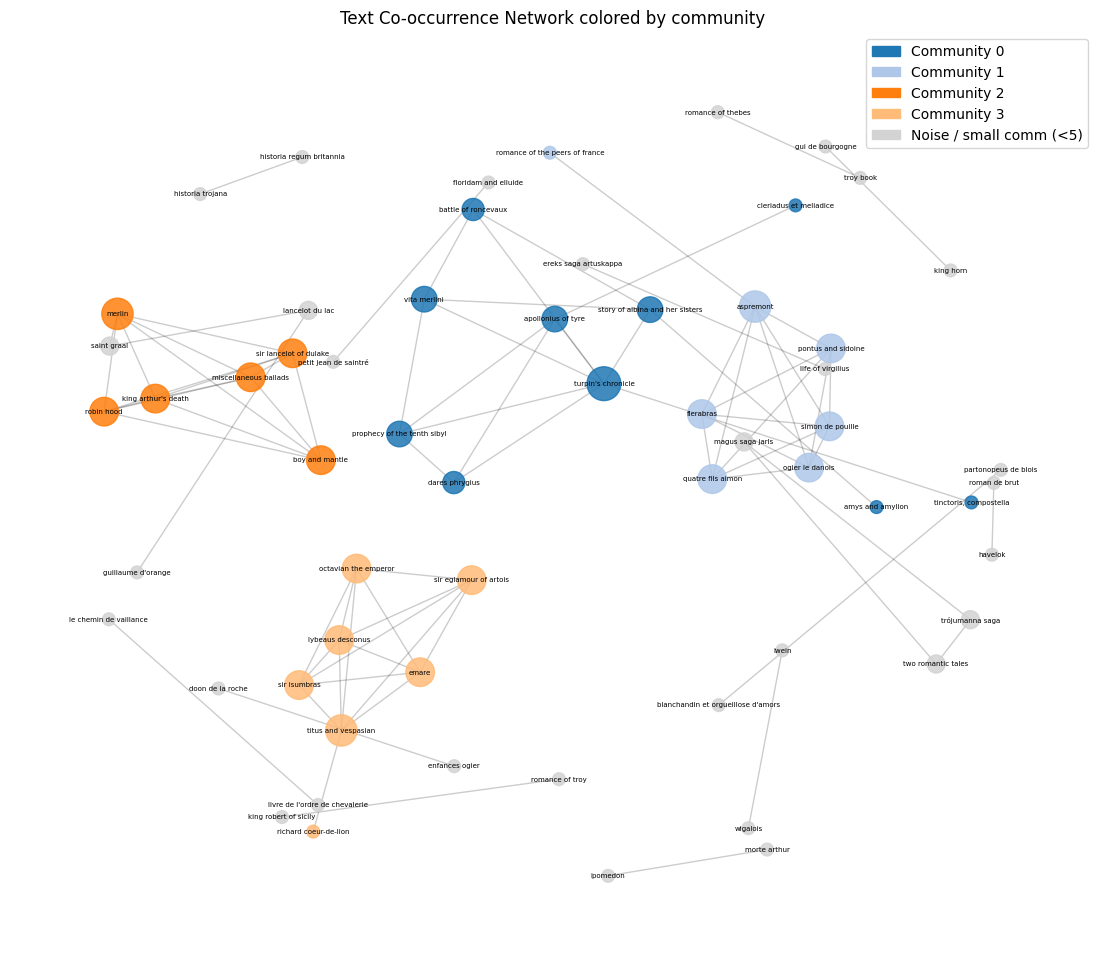

In [21]:
## 文本联系得越紧密，说明越可能共同传播

G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')
print(f"basic attributes of G :\n"
     f"{nx.average_clustering(G)}\n"
    f"{nx.degree_centrality(G)}\n"
    f"{nx.betweenness_centrality(G)}\n"
)


# 按照节点的degree centrality计算节点大小，和颜色
# top_n=20
degree = nx.degree_centrality(G)
# top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
node_sizes = [degree[n]*5000 for n in G.nodes()]



# 给每一个comm分配颜色
cmap = plt.cm.tab20
color_map = {
    label: ("lightgray" if label == -1 else cmap(i))
    for i, label in enumerate([l for l in labels if l != -1])
}
color_map[-1] = "lightgray"

# 映射回每一个节点
node_colors = [color_map[community_map[n]] for n in G.nodes()]
print(f"node_colors: {node_colors}\n")

# LAYOUT!!!
# layout 只是可视化，不改变网络结构 但它会“强烈影响你对结构的直觉判断”
# 所以需要分开解释community（算法）和layout（展示）
# pos = nx.spring_layout(G, k=0.3, seed=42)
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)# k越大，节点越分散
# pos = nx.kamada_kawai_layout(G)#节点分布更加均匀


plt.figure(figsize=(14,12))

# 画节点
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    # cmap=cmap,  
    alpha=0.85
)

# 画边
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2
)

# 标注所有节点：
nx.draw_networkx_labels(
    G, pos,
    font_size=5,
    font_color='black'
)

# legend
import matplotlib.patches as mpatches
handles = []
for label in labels:
    if label == -1:
        handles.append(mpatches.Patch(color="lightgray", label=f"Noise / small comm (<{min_comm_size})"))
    else:
        handles.append(
            mpatches.Patch(color=color_map[label], label=f"Community {label}")
        )

plt.legend(handles=handles, loc="best")
plt.title(f"Text Co-occurrence Network colored by community")
plt.axis('off')
plt.show()


## colored by THEME

In [22]:
print(len(df_))

node_theme_map = df_.set_index("title_index")["theme"].to_dict()#***着色标准
print(node_theme_map)
labels = list(set(node_theme_map.values()))
print(labels)

413
{'heroica': 'classical romances', 'iliaca': 'classical romances', 'dictys cretensis': 'classical romances', 'dares phrygius': 'classical romances', 'roman de troie': 'appendix', 'historia trojana': 'classical romances', 'trójumanna saga': 'classical romances', 'rimur from trójumanna saga': 'classical romances', 'history of troy': 'classical romances', 'filostrato': 'classical romances', 'troilus and cryseyde': 'classical romances', 'troy book': 'classical romances', "roman d'eneas": 'classical romances', 'romance of troy': 'classical romances', 'romance of thebes': 'classical romances', 'romance of jason': 'classical romances', 'alexandreis': 'classical romances', 'alexander saga': 'classical romances', 'marvels of india': 'classical romances', 'treatise on the brahmins': 'classical romances', 'letters of dindimus to alexander the great': 'classical romances', "la vengeance d'alexandre": 'classical romances', 'voeux du paon': 'appendix', 'florimont': 'classical romances', 'apolloni

basic attributes of G :
0.41111111111111115
{'apollonius of tyre': 0.06779661016949153, 'cleriadus et meliadice': 0.01694915254237288, 'prophecy of the tenth sibyl': 0.06779661016949153, "turpin's chronicle": 0.11864406779661017, 'aspremont': 0.1016949152542373, 'fierabras': 0.0847457627118644, 'ogier le danois': 0.0847457627118644, 'quatre fils aimon': 0.0847457627118644, 'romance of the peers of france': 0.01694915254237288, 'simon de pouille': 0.0847457627118644, 'boy and mantle': 0.0847457627118644, "king arthur's death": 0.0847457627118644, 'miscellaneous ballads': 0.0847457627118644, 'robin hood': 0.0847457627118644, 'dares phrygius': 0.05084745762711865, 'emare': 0.0847457627118644, 'octavian the emperor': 0.0847457627118644, 'sir eglamour of artois': 0.0847457627118644, 'sir isumbras': 0.0847457627118644, 'enfances ogier': 0.01694915254237288, 'doon de la roche': 0.01694915254237288, 'historia trojana': 0.01694915254237288, 'historia regum britannia': 0.01694915254237288, 'iwei

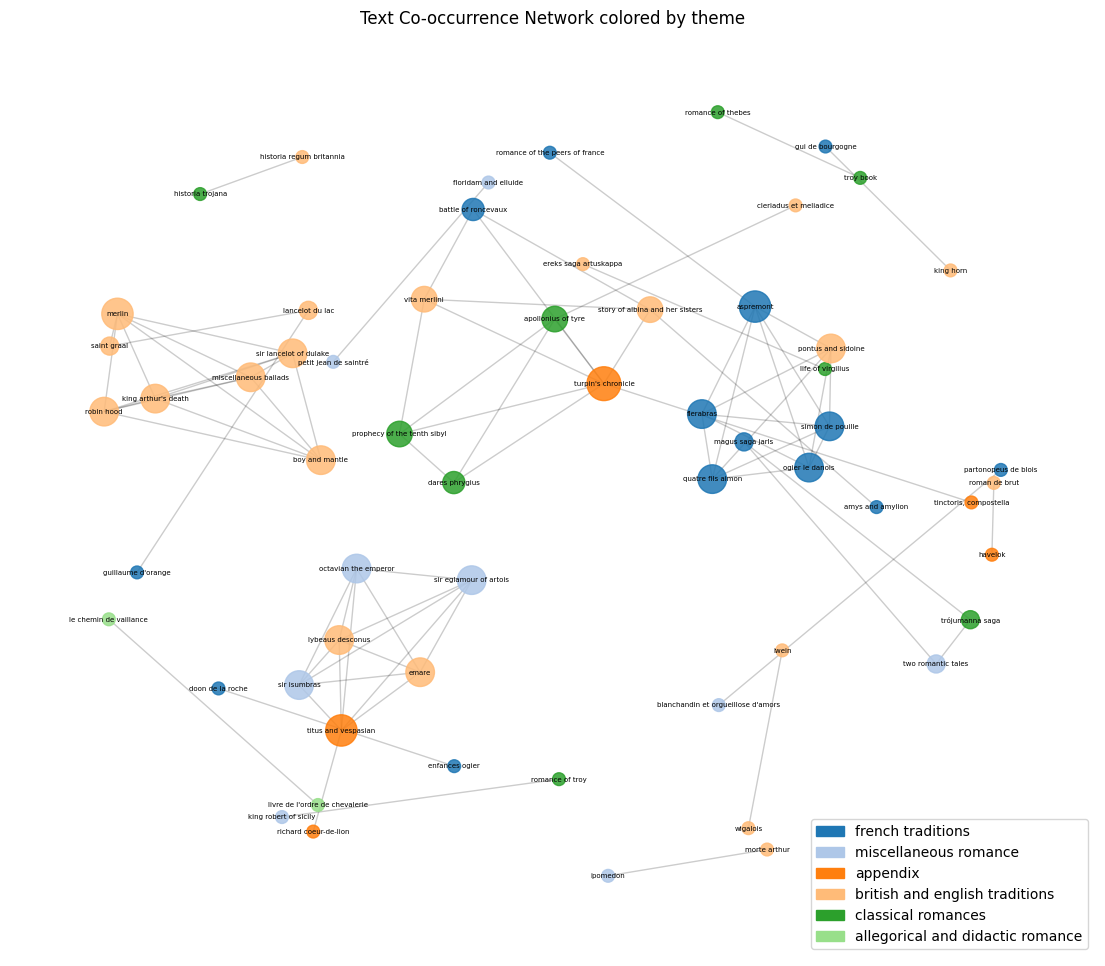

In [23]:
G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')
print(f"basic attributes of G :\n"
     f"{nx.average_clustering(G)}\n"
    f"{nx.degree_centrality(G)}\n"
    f"{nx.betweenness_centrality(G)}\n"
)


# 按照节点的degree centrality计算节点大小，和颜色
# top_n=20
degree = nx.degree_centrality(G)
# top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
node_sizes = [degree[n]*5000 for n in G.nodes()]


# 给每一个comm分配颜色
cmap = plt.cm.tab20
color_map = {
    label: ("lightgray" if label == "unknown" else cmap(i))
    for i, label in enumerate([l for l in labels if l != -1])
}
color_map["unknown"] = "lightgray"

# 映射回每一个节点
node_colors = [color_map[node_theme_map[n]] for n in G.nodes()]
print(f"node_colors: {node_colors}\n")

# LAYOUT!!!
# layout 只是可视化，不改变网络结构 但它会“强烈影响你对结构的直觉判断”
# 所以需要分开解释community（算法）和layout（展示）
# pos = nx.spring_layout(G, k=0.3, seed=42)
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)# k越大，节点越分散
# pos = nx.kamada_kawai_layout(G)#节点分布更加均匀


plt.figure(figsize=(14,12))

# 画节点
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    # cmap=cmap,  
    alpha=0.85
)

# 画边
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2
)

# 标注所有节点：
nx.draw_networkx_labels(
    G, pos,
    font_size=5,
    font_color='black'
)

# legend
import matplotlib.patches as mpatches
handles = []
for label in labels:
    if label == -1:
        handles.append(mpatches.Patch(color="lightgray", label=f"Unknown genre"))
    else:
        handles.append(
            mpatches.Patch(color=color_map[label], label=f"{label}")
        )

plt.legend(handles=handles, loc="best")
plt.title(f"Text Co-occurrence Network colored by theme")
plt.axis('off')
plt.show()


### CENT?/MATERIAL/SIZE

In [24]:
print(df['size_class'].value_counts(),"\n")

## color_map
node_theme_map = df_.set_index("title_index")["size_class"].to_dict()#***着色标准
print(node_theme_map)
labels = list(set(node_theme_map.values()))
print(labels)

size_class
folio     199
quarto    183
octavo     55
Name: count, dtype: int64 

{'heroica': 'quarto', 'iliaca': 'quarto', 'dictys cretensis': 'octavo', 'dares phrygius': 'quarto', 'roman de troie': 'octavo', 'historia trojana': 'folio', 'trójumanna saga': 'folio', 'rimur from trójumanna saga': 'folio', 'history of troy': nan, 'filostrato': 'folio', 'troilus and cryseyde': 'quarto', 'troy book': nan, "roman d'eneas": 'folio', 'romance of troy': 'quarto', 'romance of thebes': 'folio', 'romance of jason': 'folio', 'alexandreis': 'folio', 'alexander saga': 'folio', 'marvels of india': nan, 'treatise on the brahmins': nan, 'letters of dindimus to alexander the great': 'folio', "la vengeance d'alexandre": 'folio', 'voeux du paon': 'quarto', 'florimont': 'folio', 'apollonius of tyre': 'folio', 'sir orpheo': nan, "roman d'athis et profilas": 'quarto', 'titus and vespasian': 'quarto', 'prophecy of the tenth sibyl': nan, 'life of virgilius': 'quarto', 'story of albina and her sisters': 'quarto'

basic attributes of G :
0.41111111111111115
{'apollonius of tyre': 0.06779661016949153, 'cleriadus et meliadice': 0.01694915254237288, 'prophecy of the tenth sibyl': 0.06779661016949153, "turpin's chronicle": 0.11864406779661017, 'aspremont': 0.1016949152542373, 'fierabras': 0.0847457627118644, 'ogier le danois': 0.0847457627118644, 'quatre fils aimon': 0.0847457627118644, 'romance of the peers of france': 0.01694915254237288, 'simon de pouille': 0.0847457627118644, 'boy and mantle': 0.0847457627118644, "king arthur's death": 0.0847457627118644, 'miscellaneous ballads': 0.0847457627118644, 'robin hood': 0.0847457627118644, 'dares phrygius': 0.05084745762711865, 'emare': 0.0847457627118644, 'octavian the emperor': 0.0847457627118644, 'sir eglamour of artois': 0.0847457627118644, 'sir isumbras': 0.0847457627118644, 'enfances ogier': 0.01694915254237288, 'doon de la roche': 0.01694915254237288, 'historia trojana': 0.01694915254237288, 'historia regum britannia': 0.01694915254237288, 'iwei

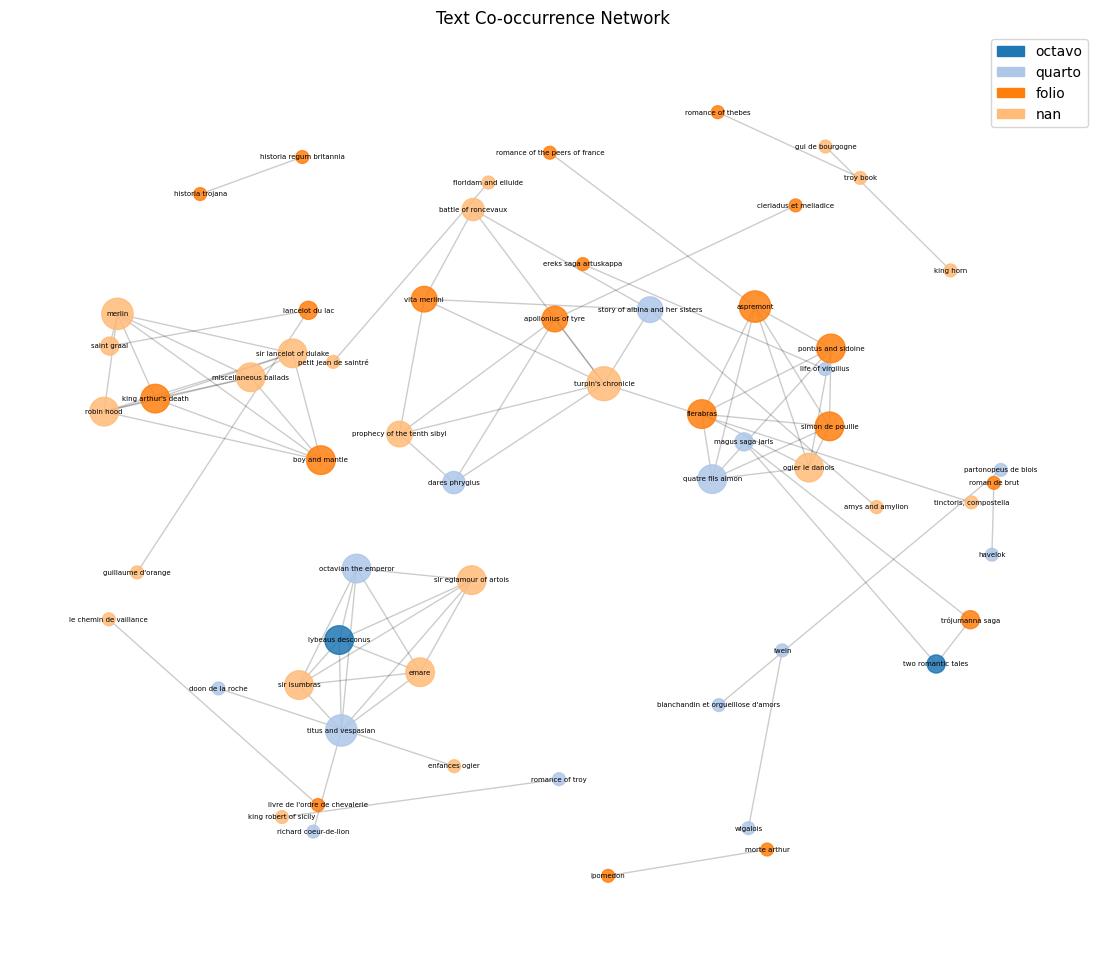

In [25]:
G = nx.from_pandas_edgelist(proj_df, 'source', 'target', edge_attr='weight')
print(f"basic attributes of G :\n"
     f"{nx.average_clustering(G)}\n"
    f"{nx.degree_centrality(G)}\n"
    f"{nx.betweenness_centrality(G)}\n"
)


# 按照节点的degree centrality计算节点大小，和颜色
# top_n=20
degree = nx.degree_centrality(G)
# top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
node_sizes = [degree[n]*5000 for n in G.nodes()]


# 给每一个comm分配颜色
cmap = plt.cm.tab20
color_map = {
    label: ("lightgray" if label == "unknown" else cmap(i))
    for i, label in enumerate([l for l in labels if l != -1])
}
color_map["unknown"] = "lightgray"



# 映射回每一个节点
node_colors = [color_map[node_theme_map[n]] for n in G.nodes()]
print(f"node_colors: {node_colors}\n")

# LAYOUT!!!
# layout 只是可视化，不改变网络结构 但它会“强烈影响你对结构的直觉判断”
# 所以需要分开解释community（算法）和layout（展示）
# pos = nx.spring_layout(G, k=0.3, seed=42)
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)# k越大，节点越分散
# pos = nx.kamada_kawai_layout(G)#节点分布更加均匀


plt.figure(figsize=(14,12))

# 画节点
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    # cmap=cmap,  
    alpha=0.85
)

# 画边
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2
)

# 标注所有节点：
nx.draw_networkx_labels(
    G, pos,
    font_size=5,
    font_color='black'
)

# legend
import matplotlib.patches as mpatches
handles = []
for label in labels:
    if label == -1:
        handles.append(mpatches.Patch(color="lightgray", label=f"Unknown genre"))
    else:
        handles.append(
            mpatches.Patch(color=color_map[label], label=f"{label}")
        )

plt.legend(handles=handles, loc="best")
plt.title(f"Text Co-occurrence Network")
plt.axis('off')
plt.show()